In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df =pd.read_csv("/content/Retail_Dataset_Cleaned (11).csv")

In [12]:
df.head()
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5146 entries, 0 to 5145
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_ID               5146 non-null   object 
 1   Store_Name             5146 non-null   object 
 2   Brand_Name             5146 non-null   object 
 3   Store_Type             5146 non-null   object 
 4   City                   5146 non-null   object 
 5   City_Tier              5146 non-null   object 
 6   Product_Name           5146 non-null   object 
 7   Category               5146 non-null   object 
 8   Sub_Category           5146 non-null   object 
 9   Product_Stage          5146 non-null   object 
 10  Quantity_Available     5146 non-null   float64
 11  Units_Sold             5146 non-null   float64
 12  Unit_Price             5146 non-null   int64  
 13  Cost_Price             5146 non-null   int64  
 14  Revenue                5146 non-null   float64
 15  Prof

Index(['Store_ID', 'Store_Name', 'Brand_Name', 'Store_Type', 'City',
       'City_Tier', 'Product_Name', 'Category', 'Sub_Category',
       'Product_Stage', 'Quantity_Available', 'Units_Sold', 'Unit_Price',
       'Cost_Price', 'Revenue', 'Profit_Margin', 'Average_Order_Value',
       'Inventory_Turnover', 'Days_of_Stock', 'Customer_Segment',
       'Sales_Channel', 'Payment_Method', 'Supplier', 'Supplier_Rating',
       'Promotion_Type', 'Promotion_Impact', 'Max_Discount_Offered',
       'Return_Rate', 'Return_Reason', 'Customer_Satisfaction',
       'Online_Rating', 'Review_Count', 'Sales_Rep_Experience',
       'Sales_Rep_Rating', 'Market_Share', 'Competition_Level',
       'Competitor_Count', 'Brand_Loyalty', 'Brand_Awareness',
       'Price_Competitiveness', 'Weather_Impact', 'Delivery_Time',
       'Shipping_Cost', 'Month', 'Year', 'Quarter', 'Season'],
      dtype='object')

In [46]:
df.shape

(5146, 47)

In [13]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

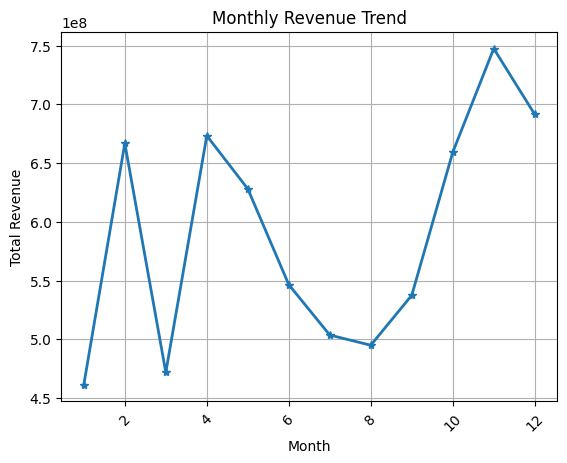

In [24]:
plt.plot(monthly_revenue.index,
         monthly_revenue.values,
         marker='*',
         linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

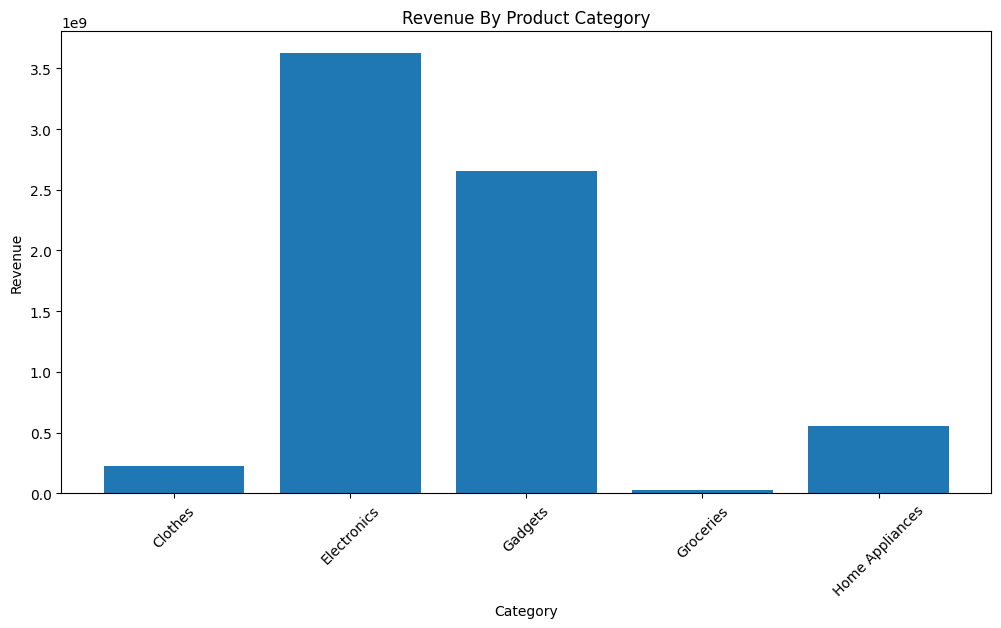

In [26]:
from matplotlib import figure
category_revenue = df.groupby('Category')['Revenue'].sum()
plt.figure(figsize=(12,6))
plt.bar(category_revenue.index,
        category_revenue.values)

plt.title('Revenue By Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

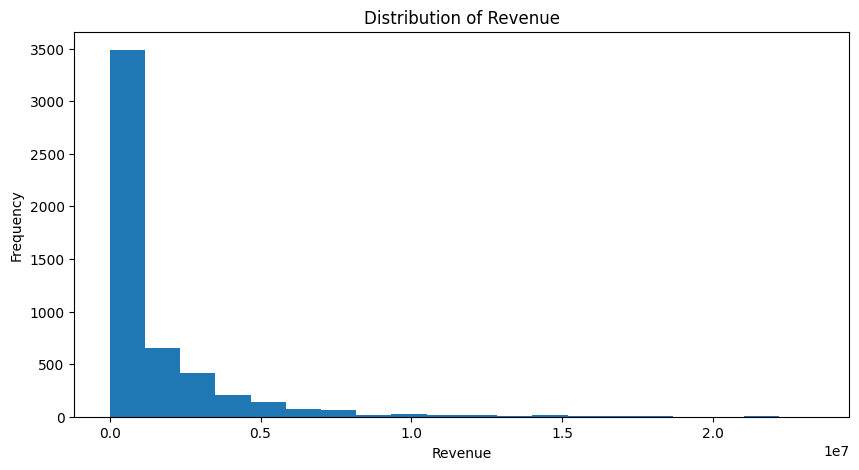

In [27]:
plt.figure(figsize=(10, 5))
plt.hist(df['Revenue'],
         bins=20)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.show()

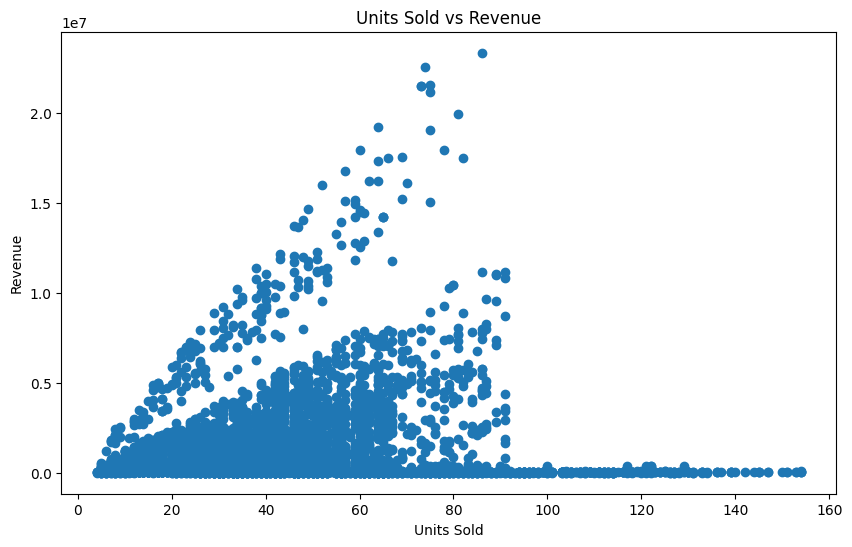

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Units_Sold'],
            df['Revenue'])

plt.title('Units Sold vs Revenue')
plt.xlabel('Units Sold')
plt.ylabel('Revenue')

plt.show()

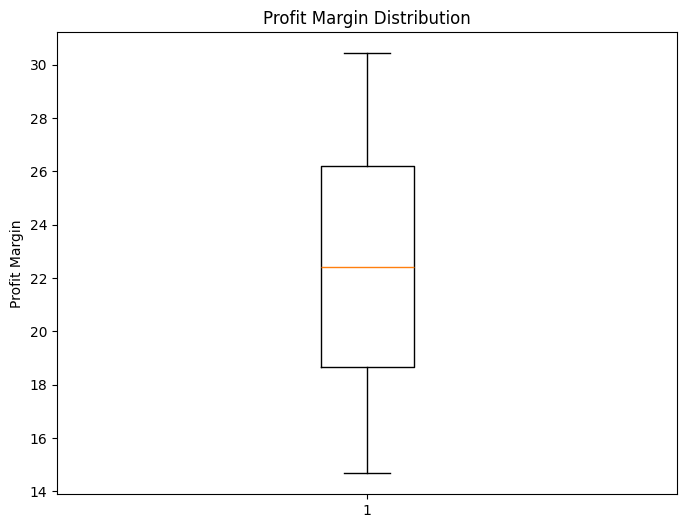

In [29]:
plt.figure(figsize=(8, 6))
plt.boxplot(df['Profit_Margin'])
plt.title('Profit Margin Distribution')
plt.ylabel('Profit Margin')
plt.show()

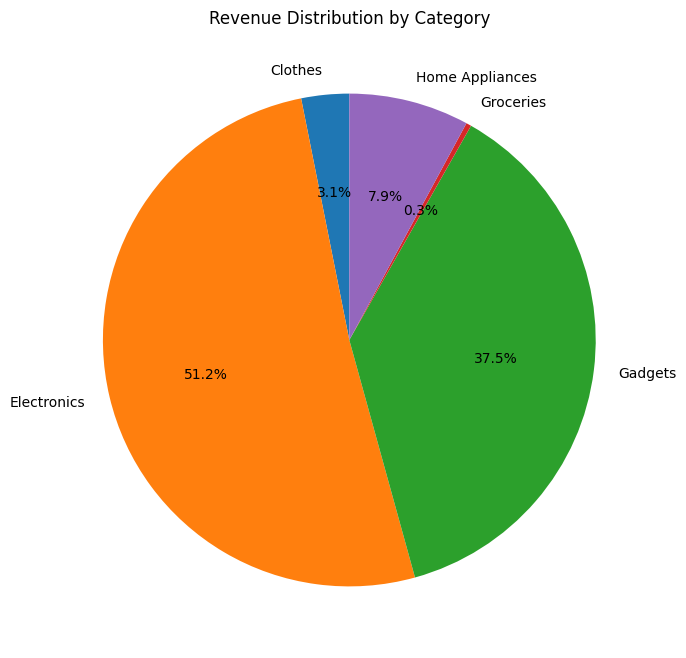

In [30]:
category_revenue = df.groupby('Category')['Revenue'].sum()

# Create Pie Chart
plt.figure(figsize=(8, 8))

plt.pie(category_revenue,
        labels=category_revenue.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Revenue Distribution by Category')

plt.show()

Text(0.5, 1.0, 'Count of Products by Category')

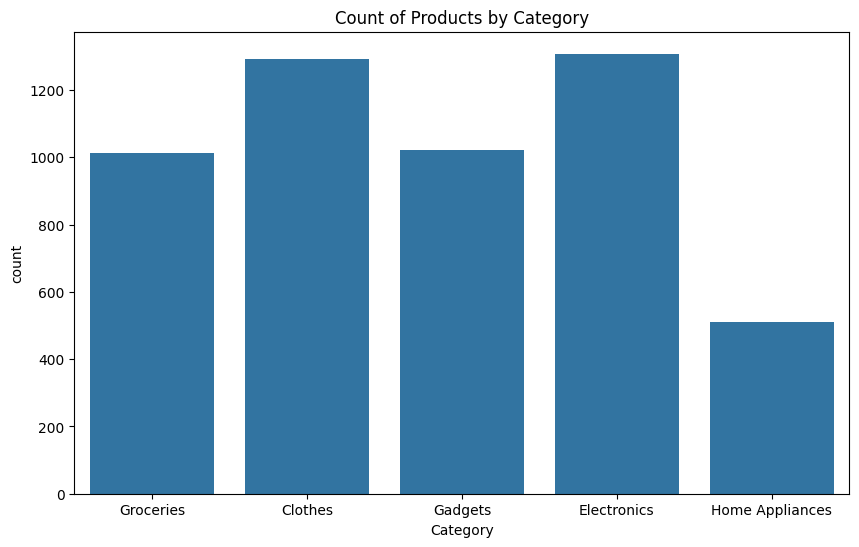

In [31]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Category')

plt.title('Count of Products by Category')

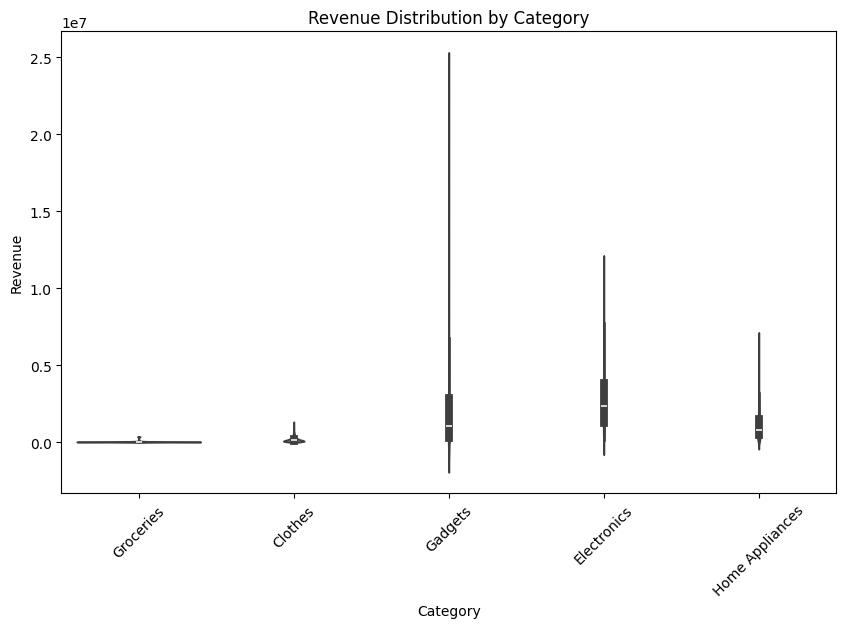

In [32]:
plt.figure(figsize=(10, 6))

sns.violinplot(data=df,
               x='Category',
               y='Revenue')

plt.title('Revenue Distribution by Category')
plt.xticks(rotation=45)

plt.show()

In [33]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(18,12))

<Figure size 1800x1200 with 0 Axes>

<Figure size 1800x1200 with 0 Axes>

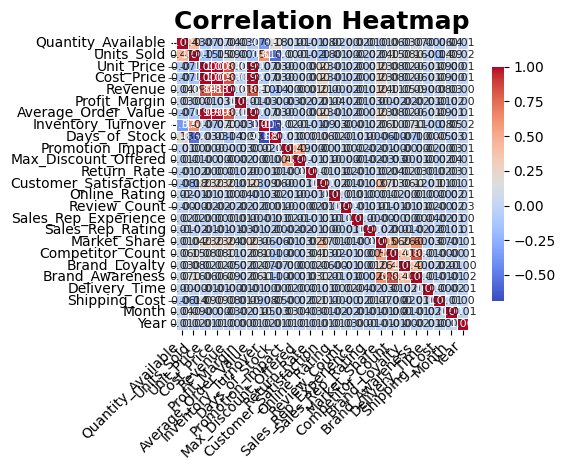

In [35]:
# Create heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'shrink': 0.8}
)

# Customize chart
plt.title('Correlation Heatmap', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

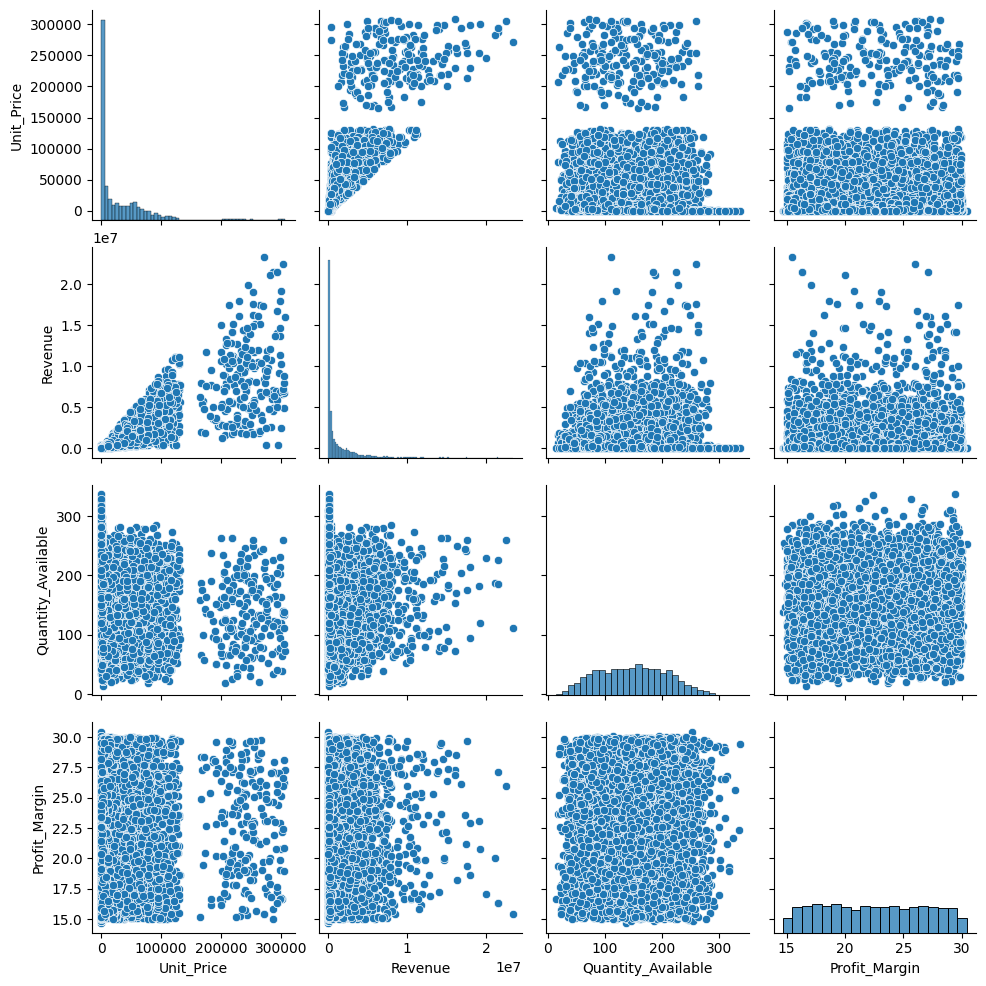

In [36]:
sns.pairplot(df[['Unit_Price',
                 'Revenue',
                 'Quantity_Available',
                 'Profit_Margin']])

plt.show()

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 72.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 83.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 77.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 87.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 64.0% of the points cannot be plac

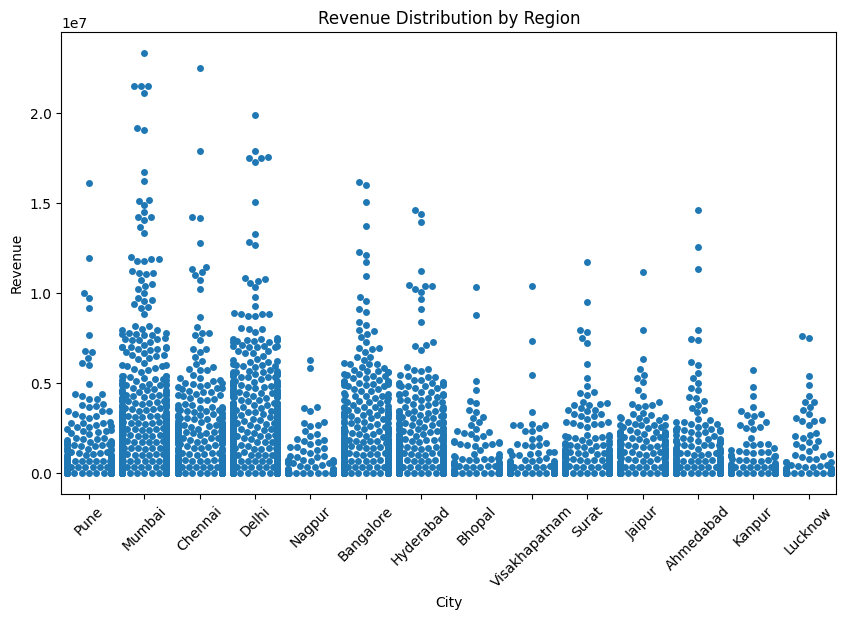

In [37]:
plt.figure(figsize=(10, 6))

sns.swarmplot(data=df,
              x='City',
              y='Revenue')

plt.title('Revenue Distribution by Region')
plt.xticks(rotation=45)

plt.show()

In [38]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

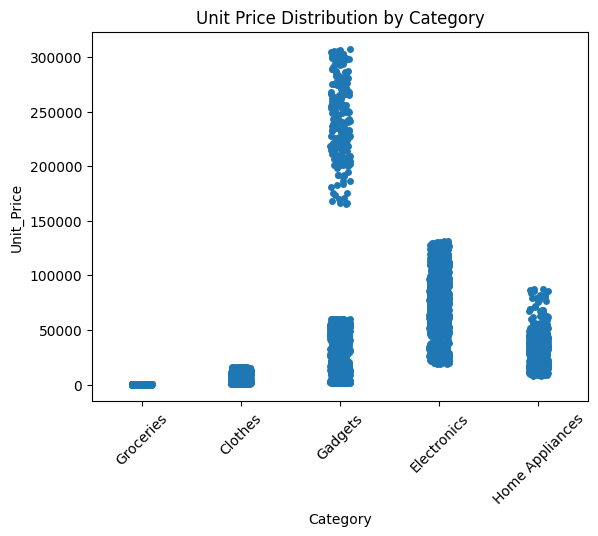

In [39]:
sns.stripplot(data=df,
              x='Category',
              y='Unit_Price',
              jitter=True)

plt.title('Unit Price Distribution by Category')
plt.xticks(rotation=45)

plt.show()

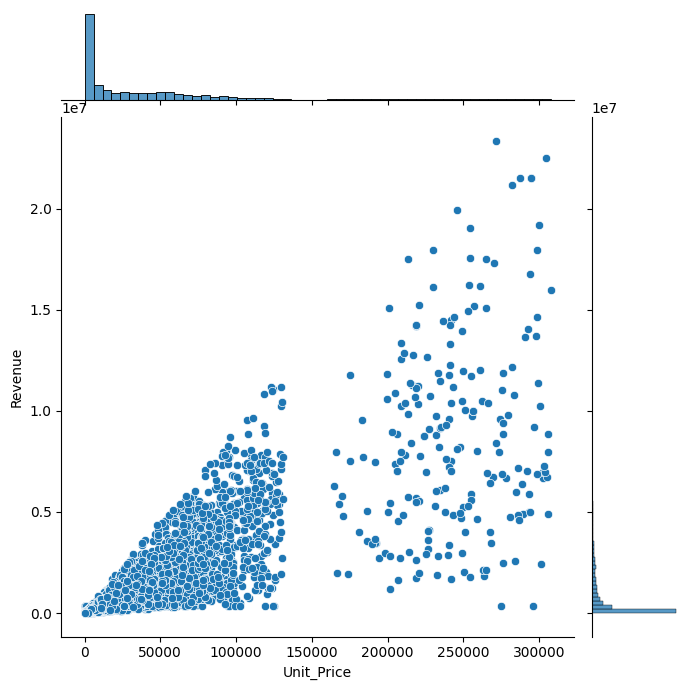

In [40]:
sns.jointplot(data=df,
              x='Unit_Price',
              y='Revenue',
              kind='scatter',
              height=7)

plt.show()

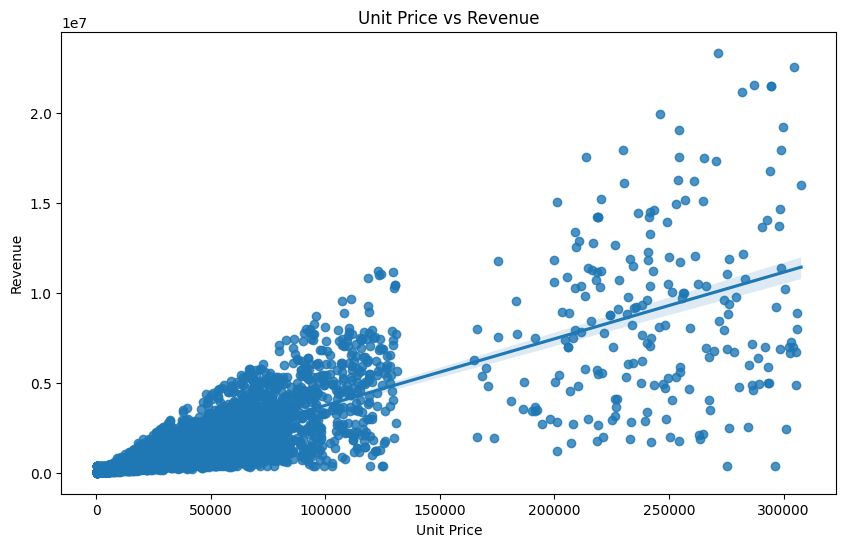

In [41]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df,
            x='Unit_Price',
            y='Revenue')

plt.title('Unit Price vs Revenue')
plt.xlabel('Unit Price')
plt.ylabel('Revenue')

plt.show()

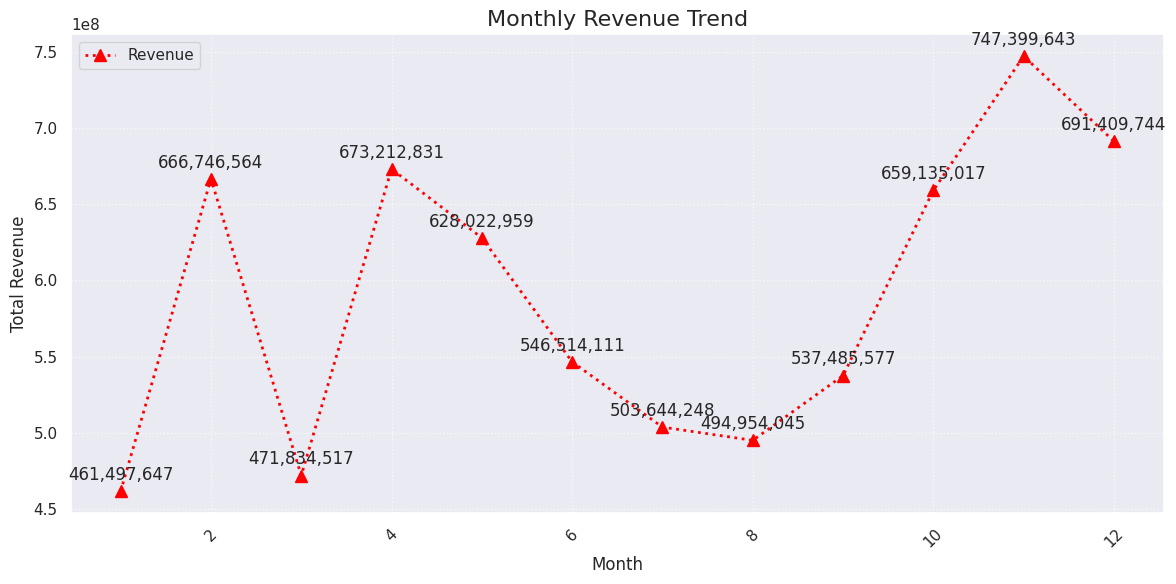

In [54]:
# Apply Seaborn Theme
sns.set_theme(style="darkgrid")

# Prepare Data
monthly_revenue = df.groupby('Month')['Revenue'].sum()

# Change Figure Size
plt.figure(figsize=(12, 6))

# Create Line Chart with Color, Marker, and Line Style
plt.plot(monthly_revenue.index,
         monthly_revenue.values,
         color='red',
         marker='^',
         linestyle=':',
         linewidth=2,
         markersize=8,
         label='Revenue')

# Add Title
plt.title('Monthly Revenue Trend', fontsize=16)

# Add X-axis and Y-axis Labels
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
# Rotate Axis Labels
plt.xticks(rotation=45)

# Add Grid Lines
plt.grid(True, linestyle=':', alpha=0.7)

# Add Legend
plt.legend()

# Add Annotations/Data Labels
for x, y in zip(monthly_revenue.index,
                monthly_revenue.values):
    plt.annotate(f'{y:,.0f}',
                 (x, y),
                 textcoords='offset points',
                 xytext=(0, 8),
                 ha='center')

# Adjust Layout
plt.tight_layout()

# Display Chart
plt.show()